## Loading

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

matches = pd.read_csv('./datasets/KaggleMatches.csv',low_memory=False).set_index('tourney_id')
players = pd.read_csv('./datasets/KagglePlayers.csv').set_index('player_id')

matches = matches[matches['league']=='atp'] #selecting only atp matches
players = players[players['gender']=='male'] # selecting only male players

surfaces = ['Hard','Clay','Grass']#removing all the other surfaces except the major ones
matches = matches[matches['surface'].isin(surfaces)]


## Cleaning

In [2]:

players['name'] = players['name_first'] +" "+ players['name_last']
players.drop((i for i in ['name_first', 'name_last']) ,axis =1,inplace=True)
players['birthdate'] = pd.to_datetime(players['birthdate'].dropna().astype(int).astype(str),format="%Y%m%d",errors = 'coerce')

In [3]:
# these dont seem relevant to my analysis
removed_columns = ['match_num','winner_seed','winner_id','loser_id','loser_seed','loser_entry','winner_entry']

for i in removed_columns:
    matches.drop(i,axis =1,inplace=True)

# Convert numerical values to float
numeric_columns = ['w_ace', 'l_ace', 'w_df', 'l_df', 'w_bpSaved', 'l_bpSaved', 'winner_rank', 'loser_rank', 'winner_age', 'loser_age', 'winner_ht', 'loser_ht', 'w_svpt', 'l_svpt', 'minutes']
matches[numeric_columns] = matches[numeric_columns].astype(float)

# Define the function to extract date features
def extract_date_features(df, date_column):
    # Convert the date column to datetime format if needed
    if not pd.api.types.is_datetime64_any_dtype(df[date_column]):
        df[date_column] = pd.to_datetime(df[date_column])

    # Extract year, month, and day
    df['tourney_year'] = df[date_column].dt.year
    df['tourney_month'] = df[date_column].dt.month
    return df

# Define the date column
date_column = 'tourney_date'

# Extract date features from the train dataset
matches = extract_date_features(matches, date_column)
def rename_columns(col):
    '''This function renames the dataframe column title'''
    if col.startswith('tourney_'):
           col = 't_' + ''.join(col.split('_')[1:])
           return col 
    elif col.startswith('loser_'):
             col = 'l_' + ''.join(col.split('_')[1:])
             return col 
    elif col.startswith("winner_"):
              col = "w_" + ''.join(col.split('_')[1:])
              return  col
    else:
       return col

matches.rename(columns=rename_columns,  inplace=True)

In [4]:
w_years = matches.groupby(['w_name']).agg(f_year=('t_year','min'),l_year=('t_year','max')).fillna(0).reset_index()
w_years.rename(columns={'w_name':'name'},inplace = True)
l_years = matches.groupby(['l_name']).agg(f_year=('t_year','min'),l_year=('t_year','max')).fillna(0).reset_index()
l_years.rename(columns={'l_name':'name'},inplace = True)

player_years = pd.merge(w_years,l_years,on ='name',how = 'outer',suffixes=('_w','_l'))
player_years['f_year'] = player_years[['f_year_w','f_year_l']].min(axis=1)
player_years['l_year'] = player_years[['l_year_w','l_year_l']].max(axis=1)

#Converting the year columns into datetime objects
player_years['f_year'] = player_years['f_year'].astype('int32')
player_years['f_year'] = pd.to_datetime(player_years['f_year'],format ="%Y").dt.year

player_years['l_year'] = player_years['l_year'].astype('int32')
player_years['l_year'] = pd.to_datetime(player_years['l_year'],format ="%Y").dt.year

players_years =player_years.drop(['f_year_w','l_year_w','l_year_l','f_year_l'],axis =1,inplace=True)

player_years['career_duration'] = (player_years['l_year'] - player_years['f_year']) + 1

sw = matches.groupby(['w_name']).agg({'w_df':'sum','w_ace':'sum','w_svpt':'sum','w_1stIn':'sum','w_1stWon':'sum','w_2ndWon':'sum','w_SvGms':'sum','w_bpSaved':'sum','w_bpFaced':'sum'}).fillna(0)
sl = matches.groupby(['l_name']).agg({'l_df':'sum','l_ace':'sum','l_svpt':'sum','l_1stIn':'sum','l_1stWon':'sum','l_2ndWon':'sum','l_SvGms':'sum','l_bpSaved':'sum','l_bpFaced':'sum'}).fillna(0)
dfs = [sw,sl]
r = pd.concat(dfs, sort=False).reset_index().fillna(0)

r['dfs'] = r['l_df']+r['w_df']
r['aces'] = r['l_ace']+r['w_ace']
r['svpt'] = r['l_svpt']+r['w_svpt']
r['1stIn'] = r['l_1stIn']+r['w_1stIn']
r['1stWon'] = r['l_1stWon']+r['w_1stWon']
r['2ndWon'] = r['l_2ndWon']+r['w_2ndWon']
r['SvGms'] = r['l_SvGms']+r['w_SvGms']
r['bpSaved'] = r['l_bpSaved']+r['w_bpSaved']
r['bpFaced'] = r['l_bpFaced']+r['w_bpFaced']

final = r.groupby('index').agg({'dfs':'sum','aces':'sum','svpt':'sum','1stIn':'sum','1stWon':'sum','2ndWon':'sum','SvGms':'sum','bpSaved':'sum','bpFaced':'sum'})
final = final.reset_index()
final.rename(columns={'index':'name'},  inplace=True)

players = pd.merge(final,players,on='name')
players = pd.merge(player_years,players,on='name')

### Win/Loss Analysis

In [5]:
# Create a list of all unique player names
player_names = set(matches['w_name']).union(set(matches['l_name']))

# Initialize a dictionary to store win/loss data
win_loss_data = {player: {'wins': 0, 'losses': 0} for player in player_names}

# Populate the dictionary with win/loss data
for _, match in matches.iterrows():
    win_loss_data[match['w_name']]['wins'] += 1
    win_loss_data[match['l_name']]['losses'] += 1

# Convert the dictionary to a DataFrame
win_loss_df = pd.DataFrame.from_dict(win_loss_data, orient='index').reset_index()
win_loss_df.columns = ['name', 'wins', 'losses']

# Calculate win/loss ratio
win_loss_df['wlr'] = round((win_loss_df['wins'] / (win_loss_df['wins'] + win_loss_df['losses'])*100),3)

#merge players with win_loss_df
players = pd.merge(win_loss_df,players,on='name')

#total number of matches played
players['total_matches'] = players['wins'] + players ['losses']

players['serve_games_won'] = players['SvGms'] - (players['bpFaced']-players['bpSaved'])
players['serve_game_won%'] = round(players['serve_games_won'] / players['SvGms'] * 100,3) #percentage of serve games won(ability to dominate on serve)

players['break_points_saved%'] = round(players['bpSaved'] / players['bpFaced'] * 100,3)#percentage of break points saved(shows resilience in high pressure moment)

players['breakpoints_permatch'] = round(players['bpFaced'] / players['total_matches'],3)

players['ace_dominance'] = round(players['aces']/players['svpt'] * 100,3) #percentage of aces out of total points 

#players.head()
# players.to_csv('mod_players.csv',index=False)


In [6]:

# Combine 'w_name' and 't_year_quarter' into one DataFrame
winners = matches[['w_name', 't_year']].copy()
winners['result'] = 'win'

# Combine 'l_name' and 't_year_quarter' into one DataFrame
losers = matches[['l_name', 't_year']].copy()
losers['result'] = 'loss'

# Rename columns for merging
winners.columns = ['player', 't_year', 'result']
losers.columns = ['player', 't_year', 'result']

# Concatenate winners and losers
results = pd.concat([winners, losers])

# Calculate win/loss ratio for each player per quarter
win_loss_ratio = results.groupby(['player', 't_year', 'result']).size().unstack(fill_value=0)
win_loss_ratio['wlr'] = win_loss_ratio['win'] / (win_loss_ratio['win'] + win_loss_ratio['loss'])


# Track ranking at the end of each period for correlation
rankings = matches[['w_name', 'w_rank', 't_year']].drop_duplicates()
rankings.columns = ['player', 'rank', 't_year']

# Merge win/loss ratios with rankings
performance = pd.merge(win_loss_ratio.reset_index(), rankings, on=['player', 't_year'], how='left')

#Converting the year columns into datetime objects
performance['t_year'] = performance['t_year'].astype('int32')
performance['t_year'] = pd.to_datetime(performance['t_year'],format ="%Y").dt.year

# performance.to_csv('players_yearly_perfomance.csv',index=False)

# Display the performance DataFrame
# performance.head()

# Add win and loss indicators
matches['win'] = 1
matches['loss'] = 0
matches.loc[matches.index, 'loss'] = 1

# Separate wins and losses
wins = matches[['w_name', 't_year', 'surface', 'win']]
losses = matches[['l_name', 't_year', 'surface', 'loss']]

# Rename columns for consistency
wins.columns = ['player', 't_year', 'surface', 'win']
losses.columns = ['player', 't_year', 'surface', 'loss']

# Combine wins and losses
performance = pd.concat([wins, losses])

# Group by player, year, and surface
performance_grouped = performance.groupby(['player', 't_year', 'surface']).sum()
performance_grouped.reset_index(inplace=True)

# Calculate win/loss ratio
performance_grouped['wlr'] = performance_grouped['win'] / (performance_grouped['win'] + performance_grouped['loss'])

# Display the result
# performance_grouped.head()

In [7]:
def win_loss_data(col):
    '''This function returns a dataframe of the win loss ratio of a player for the different categories of a specified column name'''
    w_stats = matches.groupby(['w_name', col]).size().reset_index(name='wins')
    w_stats = w_stats.rename({'w_name':'name'},axis = 1)

    l_stats = matches.groupby(['l_name', col]).size().reset_index(name='losses')
    l_stats = l_stats.rename({'l_name':'name'},axis = 1)

    player_stats = pd.merge(w_stats, l_stats, left_on=['name', col], right_on=['name', col], how='outer')

    # Fill NaN values with 0 (players who haven't lost or won on a particular surface)
    player_stats[['losses','wins']] = player_stats[['losses','wins']].fillna(0)

    # Calculate the total matches played by each player
    player_stats['total_matches'] = player_stats['wins'] + player_stats['losses']

    # Calculate the win/loss ratio for each player
    player_stats['wlr'] = player_stats['wins'] / player_stats['total_matches']


    return player_stats

# x = win_loss_data('surface')

1. Win/Loss Ratio Over Time: Measures consistency.
2. Average Ranking Over Time: Tracks ranking progression.
3. Number of Matches Played: Indicates activity and endurance.
4. Performance on Different Surfaces: Shows adaptability.


In [ ]:
matches.head()

# Analysis by Tournament

In [ ]:
matches['t_name_x'] = matches['t_name'].copy()
tourney_years = matches.groupby(['t_name']).agg(f_year=('t_year','min'),l_year=('t_year','max')).fillna(0).reset_index()
tourney_years.rename(columns={'t_name':'name'},inplace = True)

#Converting the year columns into datetime objects
tourney_years['f_year'] = tourney_years['f_year'].astype('int32')
tourney_years['f_year'] = pd.to_datetime(tourney_years['f_year'],format ="%Y").dt.year

tourney_years['l_year'] = tourney_years['l_year'].astype('int32')
tourney_years['l_year'] = pd.to_datetime(tourney_years['l_year'],format ="%Y").dt.year

tourney_years['tournament_duration'] = (tourney_years['l_year'] - tourney_years['f_year']) + 1

final = matches.groupby(['t_name']).agg({'t_name_x':'count','w_df':'sum','w_ace':'sum','w_svpt':'sum','w_1stIn':'sum','w_1stWon':'sum','w_2ndWon':'sum','w_SvGms':'sum','w_bpSaved':'sum','w_bpFaced':'sum',
                                         'l_df':'sum','l_ace':'sum','l_svpt':'sum','l_1stIn':'sum','l_1stWon':'sum','l_2ndWon':'sum','l_SvGms':'sum','l_bpSaved':'sum','l_bpFaced':'sum',
                                         'minutes':'mean','surface':'first','best_of':'first','t_month':'first','w_name': lambda x:x.value_counts().idxmax()#most successful player
                                         }).fillna(0).reset_index()
final.rename(columns={'t_name':'name','t_name_x':'total_matches','w_name':'most_wins'},  inplace=True)

tournaments = pd.merge(tourney_years,final,on='name')

for i in list(tournaments.columns):
    if (i.startswith('w_')):
        stem  = i[2:]
        tournaments[stem] = (tournaments[f'w_{stem}'] + tournaments[f'l_{stem}'] / 2)
        tournaments.drop([f'w_{stem}',f'l_{stem}'],axis =1,inplace=True)

tournaments = round(tournaments,3)
tournaments.head(10)
# tournaments.to_csv('tournaments.csv',index=False)

### Trend Analysis


In [ ]:
def compare_trends(comp):
    comp_trend = matches.groupby(['t_year'])[[f'w_{comp}',f'l_{comp}']].mean().sort_values(by=f'w_{comp}',ascending=False).reset_index()
    comp_trend[f'avg_{comp}'] = (comp_trend[f'w_{comp}'] + comp_trend[f'l_{comp}'])/2
    plt.figure(figsize=(10, 7))
    sns.lineplot(data = comp_trend,x='t_year',y=f'w_{comp}',marker='x',label =f'w_{comp}');
    sns.lineplot(data = comp_trend,x='t_year',y=f'avg_{comp}',label =f'avg_{comp}');
    sns.lineplot(data = comp_trend,x='t_year',y=f'l_{comp}',marker='o', label=f'l_{comp}');
    plt.title(f'{comp.title()} over the Years')
    plt.xlabel('Year')
    plt.ylabel(f'{comp}')
    plt.show()

compare_trends('ace')

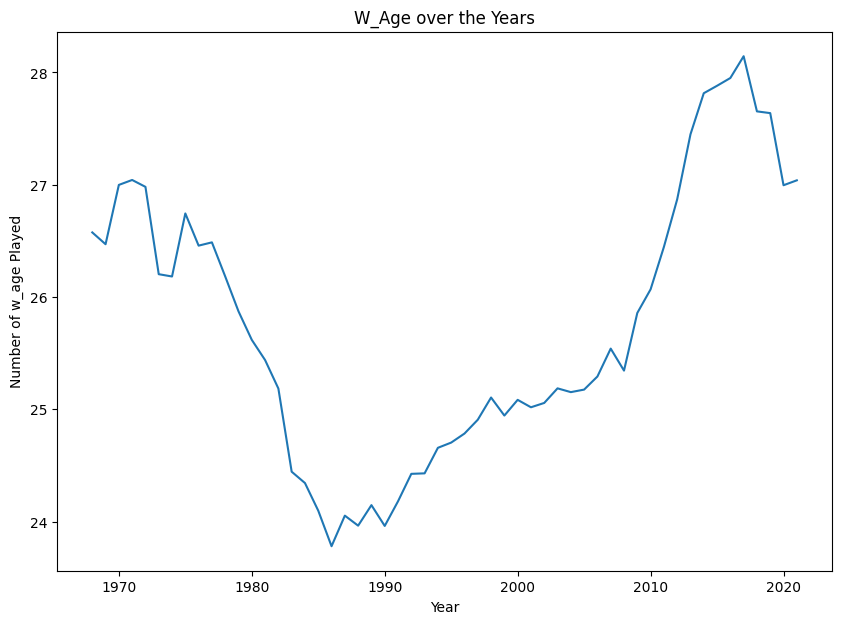

In [ ]:
def metric_per_year(metric):
    len_per_yr = matches.groupby(['t_year'])[metric].mean().sort_values(ascending=False).reset_index()
    plt.figure(figsize=(10, 7))
    sns.lineplot(data = len_per_yr,x='t_year',y=metric);

    plt.title(f'{metric.title()} over the Years')
    plt.xlabel('Year')
    plt.ylabel(f'Number of {metric} Played')
    plt.show()

metric_per_year('w_age')

In [ ]:
matches.columns

In [ ]:
metric = 'round'

average_match_duration = matches.groupby([metric])['minutes'].mean().sort_values(ascending= False)
plt.figure(figsize=(10, 7))
sns.barplot(data = average_match_duration);

plt.title(f'Time Played for {metric}')
plt.xlabel(metric)
plt.ylabel('Number of Minutes Played')
plt.show()